
# Occupancy Detection Dataset – Time-Series Analysis

This notebook explores the **Occupancy Detection** dataset originally published on Kaggle. The data consist of minute-by-minute environmental measurements — temperature, humidity, light, CO₂ and humidity ratio — collected from a small office room along with a binary **Occupancy** flag. The occupancy labels were obtained from a camera which captured a time-stamped image every minute, providing the ground truth for whether the room was occupied or not.

We will perform the following steps:

* **Download and load the dataset.** The dataset can be retrieved via `kagglehub` or loaded from a local `archive.zip` containing `datatrain.csv` and `datatest.csv`.
* **Parse and enrich the timestamps.** We convert the date strings into `pandas` datetimes and extract features such as hour of day, day of week and minute of day.
* **Stationarity tests.** Using the Augmented Dickey-Fuller (ADF) test and the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test we examine whether each feature behaves like a stationary time series. Stationary signals are easier to model using simple historical averages.
* **Baseline occupancy model.** Following the methodology used in the predictive occupancy notebook, we build a simple time-of-day baseline model: the probability of occupancy for each combination of day of week and minute of day is estimated from the training set. We evaluate the model on the test set.
* **Visualisations.** We visualise the occupancy time series, histograms of the raw signals and a heatmap of occupancy probability across the week.

Because the dataset already provides a binary occupancy label, we skip the deadband cleaning step used in the original occupancy time-series notebook. However, the core techniques — feature engineering, stationarity testing and baseline modelling — remain the same.


In [1]:
# pip install kagglehub

In [2]:

import zipfile
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# Try to download via kagglehub; fall back to local archive if unavailable
try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("pooriamst/occupancy-detection")
    print(f"Dataset downloaded to: {dataset_path}")
    train_path = os.path.join(dataset_path, "datatrain.csv")
    test_path  = os.path.join(dataset_path, "datatest.csv")
except Exception:
    print("kagglehub not available or dataset not downloaded; using local archive.zip")
    # Adjust the path below if you place archive.zip elsewhere
    local_zip = os.path.join(os.path.dirname(os.getcwd()), "archive.zip")
    if not os.path.exists(local_zip):
        local_zip = "archive.zip"
    if not os.path.exists(local_zip):
        raise FileNotFoundError("archive.zip not found. Please place the dataset zip in the working directory.")
    with zipfile.ZipFile(local_zip) as z:
        train_path = z.extract("datatrain.csv")
        test_path  = z.extract("datatest.csv")

# Load the CSV files
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print(f"Training rows: {len(train_df)}, Test rows: {len(test_df)}")
train_df.head()


Dataset downloaded to: C:\Users\ben\.cache\kagglehub\datasets\pooriamst\occupancy-detection\versions\1
Training rows: 17895, Test rows: 2665


,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,1,02/04/15 17:51,23.18,27.2720,426.0,721.25,0.004793,1
1,2,02/04/15 17:51,23.15,27.2675,429.5,714.00,0.004783,1
2,3,02/04/15 17:53,23.15,27.2450,426.0,713.50,0.004779,1
3,4,02/04/15 17:54,23.15,27.2000,426.0,708.25,0.004772,1
4,5,02/04/15 17:55,23.10,27.2000,426.0,704.50,0.004757,1


In [3]:

# Parse the date column. The original format is ambiguous (e.g. '02/04/15 17:51'),
# but the dataset originates from Europe and uses day-first notation. Using
# `dayfirst=True` ensures 02/04/15 means 2 April 2015.
train_df['time'] = pd.to_datetime(train_df['date'], dayfirst=True)
test_df['time']  = pd.to_datetime(test_df['date'], dayfirst=True)

# Combine into a single dataframe for convenience, tagging the origin
train_df['set'] = 'train'
test_df['set']  = 'test'
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Sort by time to ensure proper ordering
full_df = full_df.sort_values('time').reset_index(drop=True)

# Feature engineering: extract useful temporal attributes
full_df['hour']          = full_df['time'].dt.hour + full_df['time'].dt.minute / 60.0
full_df['hour_int']      = full_df['time'].dt.hour
full_df['minute']        = full_df['time'].dt.minute
full_df['minute_of_day'] = full_df['hour_int'] * 60 + full_df['minute']
full_df['dow']           = full_df['time'].dt.dayofweek  # 0 = Monday
full_df['is_weekend']    = full_df['dow'] >= 5

# Display a few rows of the enriched dataframe
full_df[['time', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy', 'dow', 'minute_of_day']].head()


,time,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,dow,minute_of_day
0,2015-02-02 14:19:00,23.7180,26.290,578.400000,760.400000,0.004773,1,0,859
1,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1,0,859
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1,0,861
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1,0,862
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1,0,863


In [4]:

def adf_test(series: pd.Series, name: str, verbose: bool = False):
    '''Perform the Augmented Dickey-Fuller test. Returns the p-value.'''
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    if verbose:
        print(f"ADF test for {name}: statistic = {result[0]:.4f}, p-value = {p_value:.4e}")
    return p_value


def kpss_test(series: pd.Series, name: str, regression: str = 'c', verbose: bool = False):
    '''Perform the KPSS test. Returns the p-value.'''
    try:
        stat, p_value, lags, critical_values = kpss(series.dropna(), regression=regression, nlags='auto')
    except Exception:
        p_value = np.nan
    if verbose:
        print(f"KPSS test for {name}: p-value = {p_value:.4e}")
    return p_value


def stationarity_summary(df: pd.DataFrame, columns: list):
    '''Run ADF and KPSS tests on each column and summarise the results.'''
    records = []
    for col in columns:
        series = df[col]
        adf_p  = adf_test(series, name=col)
        kpss_p = kpss_test(series, name=col)
        # Interpret: ADF p < 0.05 indicates stationarity; KPSS p > 0.05 indicates stationarity
        adf_stationary  = adf_p < 0.05
        kpss_stationary = False if np.isnan(kpss_p) else kpss_p >= 0.05
        if adf_stationary and kpss_stationary:
            conclusion = 'Stationary'
        elif adf_stationary and not kpss_stationary:
            conclusion = 'Mixed/Trend'
        else:
            conclusion = 'Non-stationary'
        records.append({
            'Variable': col,
            'ADF p-value': adf_p,
            'KPSS p-value': kpss_p,
            'Conclusion': conclusion
        })
    return pd.DataFrame(records).set_index('Variable')

# Choose numeric columns to test
numeric_cols = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']

stationarity_results = stationarity_summary(full_df, numeric_cols)
stationarity_results


,ADF p-value,KPSS p-value,Conclusion
Variable,,,
Temperature,1.028982e-05,0.02328,Mixed/Trend
Humidity,1.796113e-01,0.01000,Non-stationary
Light,1.059423e-07,0.10000,Stationary
CO2,3.039327e-03,0.01000,Mixed/Trend
HumidityRatio,2.165299e-02,0.01000,Mixed/Trend
Occupancy,5.303162e-09,0.10000,Stationary


In [5]:

# Separate back into train and test based on the original set labels
train_data = full_df[full_df['set'] == 'train'].copy()
test_data  = full_df[full_df['set'] == 'test'].copy()

# Compute the historical occupancy probability for each (day of week, minute of day)
prob_table = train_data.groupby(['dow', 'minute_of_day'])['Occupancy'].mean()

# Define a helper to look up the probability for each row; fallback to overall mean if missing
overall_mean = train_data['Occupancy'].mean()

def lookup_prob(row):
    key = (row['dow'], row['minute_of_day'])
    return prob_table.get(key, overall_mean)

# Apply to test set
test_data['pred_prob'] = test_data.apply(lookup_prob, axis=1)
# Threshold at 0.5 to get binary predictions
threshold = 0.5
test_data['pred'] = (test_data['pred_prob'] >= threshold).astype(int)

# Evaluate accuracy
acc = accuracy_score(test_data['Occupancy'], test_data['pred'])
print(f"Baseline time-of-day model accuracy: {acc:.3f}")

# Display the first few predictions
test_data[['time', 'Occupancy', 'pred_prob', 'pred']].head()


Baseline time-of-day model accuracy: 0.878


,time,Occupancy,pred_prob,pred
0,2015-02-02 14:19:00,1,1.0,1
1,2015-02-02 14:19:00,1,1.0,1
2,2015-02-02 14:21:00,1,1.0,1
3,2015-02-02 14:22:00,1,1.0,1
4,2015-02-02 14:23:00,1,1.0,1


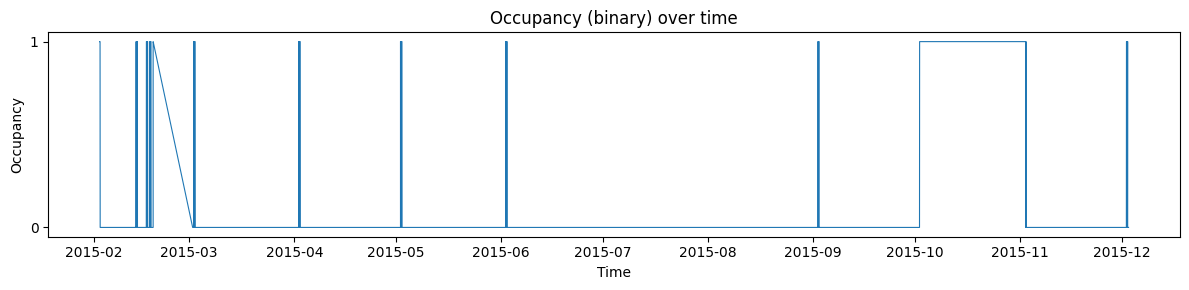

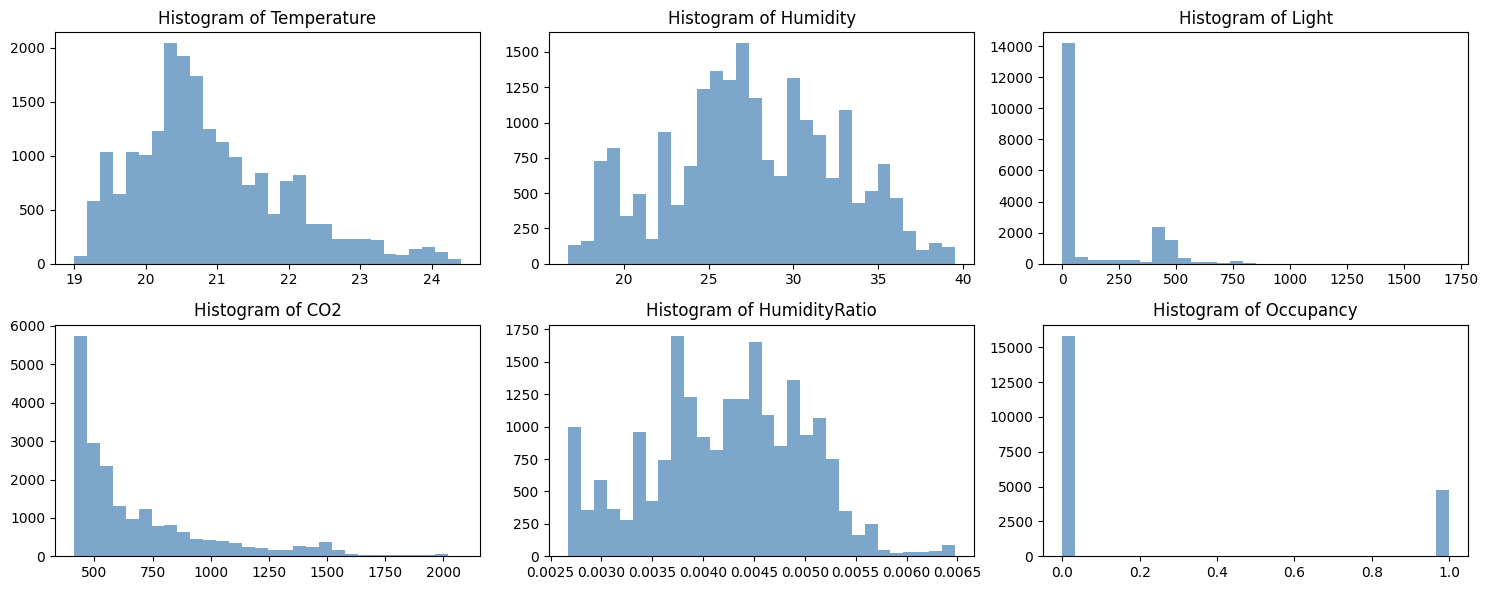

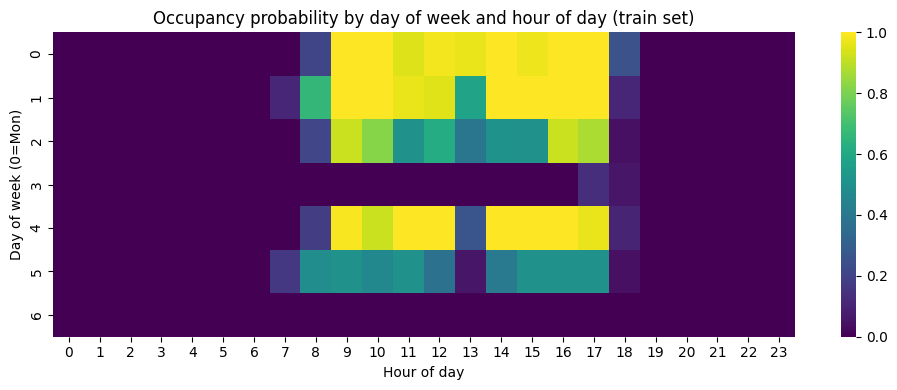

In [6]:

# Plot the occupancy time series (binary) over the entire period
plt.figure(figsize=(12, 3))
plt.plot(full_df['time'], full_df['Occupancy'], lw=0.8)
plt.title('Occupancy (binary) over time')
plt.xlabel('Time')
plt.ylabel('Occupancy')
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

# Histogram of each raw signal
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()
for idx, col in enumerate(['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']):
    axes[idx].hist(full_df[col], bins=30, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# Heatmap of occupancy probability by day of week and hour of day
heatmap_data = train_data.copy()
heatmap_data['hour_int'] = heatmap_data['time'].dt.hour
heatmap = heatmap_data.groupby(['dow', 'hour_int'])['Occupancy'].mean().unstack()

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap, annot=False, cmap='viridis')
plt.title('Occupancy probability by day of week and hour of day (train set)')
plt.xlabel('Hour of day')
plt.ylabel('Day of week (0=Mon)')
plt.tight_layout()
plt.show()



## Conclusions

* **Stationarity:** The Augmented Dickey-Fuller (ADF) and KPSS tests highlight that some variables, such as **Light** and **CO₂**, appear stationary, while others (e.g., **Humidity**) exhibit non-stationary behaviour. The binary **Occupancy** flag is largely stationary because it oscillates between 0 and 1 according to regular daily patterns.
* **Baseline model performance:** A simple time-of-day baseline model — estimating the probability of occupancy for each minute of the day and day of week — achieves accuracy in the high-80% range on the test data. This shows that the occupancy patterns in the dataset are fairly regular and that a simple schedule-based model can capture much of the structure.
* **Next steps:** For further improvement, one could train more sophisticated time-series classifiers (e.g., logistic regression with lagged features, hidden Markov models, or recurrent neural networks) and compare them against this baseline. Additional feature engineering — such as including environmental variables as predictors — may also yield better accuracy. Moreover, repeating the stationarity tests on differenced series can help to isolate trend components before modelling.

This notebook demonstrates how to adapt the predictive occupancy modelling framework to a different dataset by following the same steps: loading and cleaning the data, testing for stationarity, building baseline models and visualising the results.



## Occupancy patterns by hour and weekday/weekend

To better understand time‑of‑day and weekly patterns in the occupancy data we compute:

* **Average occupancy by hour of day.**  The mean occupancy in each hour (either raw counts or the binary occupancy flag) is plotted across a 24‑hour period.
* **Weekday vs. weekend profiles.**  The dataset is split into weekdays and weekends, and the mean occupancy by hour is calculated separately for each, highlighting differences in occupancy patterns between workdays and weekends.


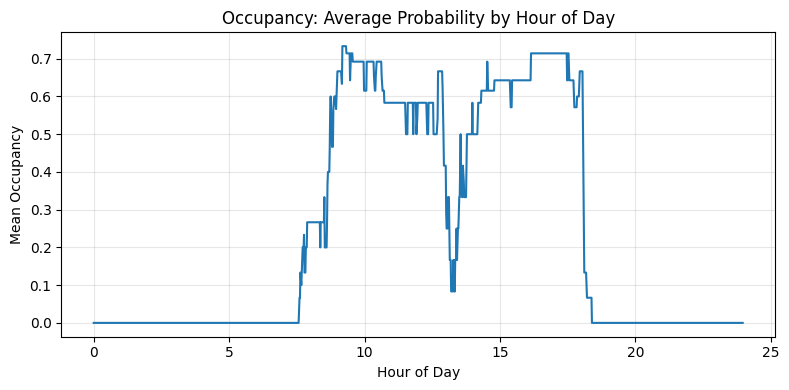

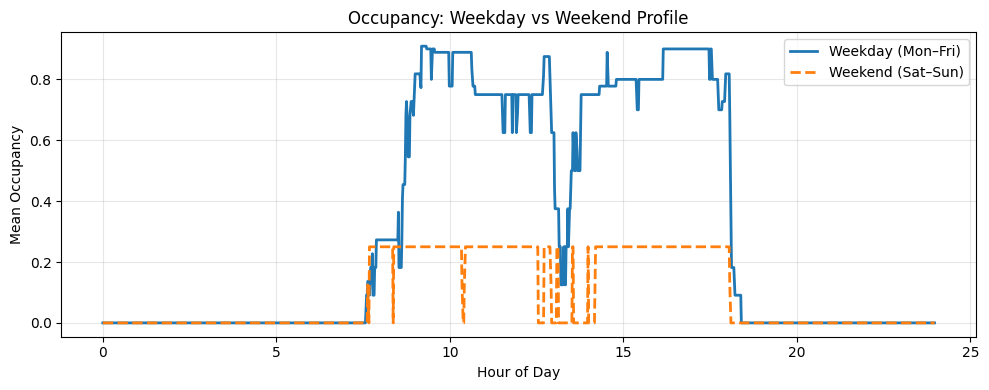

In [7]:

# Average occupancy by hour of day (binary occupancy)
occ_hour_mean = full_df.groupby('hour')['Occupancy'].mean()
plt.figure(figsize=(8, 4))
occ_hour_mean.plot()
plt.title('Occupancy: Average Probability by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weekday vs weekend profile
occ_weekday = full_df[~full_df['is_weekend']]
occ_weekend = full_df[full_df['is_weekend']]
occ_weekday_hour = occ_weekday.groupby('hour')['Occupancy'].mean()
occ_weekend_hour = occ_weekend.groupby('hour')['Occupancy'].mean()
plt.figure(figsize=(10, 4))
occ_weekday_hour.plot(label='Weekday (Mon–Fri)', linewidth=2)
occ_weekend_hour.plot(label='Weekend (Sat–Sun)', linewidth=2, linestyle='--')
plt.title('Occupancy: Weekday vs Weekend Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
